In [1]:
import pandas as pd
import os
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Constants

In [2]:
str_project = os.getcwd().split('\\')[4]
print(f'Project: {str_project}')
str_task = os.getcwd().split('\\')[5]
print(f'Task: {str_task}')
str_subtask = os.getcwd().split('\\')[6]
print(f'Subtask: {str_subtask}')

str_dirname_output = './output'

Project: 06_ml_in_python
Task: 02_application_test_model
Subtask: 04_model_building


In [3]:
os.getcwd()

'M:\\Risk Management\\Bridger Hyde\\20240521_bridger_internship\\06_ml_in_python\\02_application_test_model\\04_model_building'

In [4]:
try:
    os.mkdir(str_dirname_output)
except FileExistsError:
    pass

# pull in datasets

In [5]:
dftrainset = pd.read_csv('M:\\Risk Management\\Bridger Hyde\\20240521_bridger_internship\\06_ml_in_python\\02_application_test_model\\03_data_preprocessing\\output\\trainingset.csv')
dftestset = pd.read_csv('M:\\Risk Management\\Bridger Hyde\\20240521_bridger_internship\\06_ml_in_python\\02_application_test_model\\03_data_preprocessing\\output\\testset.csv')

# Model build

In [6]:
# select the categorical columns
categorical_cols = dftrainset.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_cols)

['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [7]:
# seperate features and target
X = dftrainset.drop('TARGET', axis=1)
y = dftrainset['TARGET']

In [8]:
# split the data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
#X_train = dftrainset.drop(columns=['TARGET', 'rownum','SK_ID_CURR','FLAG_DOCUMENT_20','FLAG_DOCUMENT_7','FLAG_DOCUMENT_4','FLAG_DOCUMENT_10','FLAG_MOBIL','FLAG_CONT_MOBILE','FLAG_DOCUMENT_2','FLAG_DOCUMENT_12','FLAG_DOCUMENT_21'])
#y_train = dftrainset['TARGET']

#X_valid = dfvalidset.drop(columns=['TARGET','rownum','SK_ID_CURR','FLAG_DOCUMENT_20','FLAG_DOCUMENT_7','FLAG_DOCUMENT_4','FLAG_DOCUMENT_10','FLAG_MOBIL','FLAG_CONT_MOBILE','FLAG_DOCUMENT_2','FLAG_DOCUMENT_12','FLAG_DOCUMENT_21'])
#y_valid = dfvalidset['TARGET']

#X_test = dftestset.drop(columns=['SK_ID_CURR','FLAG_DOCUMENT_20','FLAG_DOCUMENT_7','FLAG_DOCUMENT_4','FLAG_DOCUMENT_10','FLAG_MOBIL','FLAG_CONT_MOBILE','FLAG_DOCUMENT_2','FLAG_DOCUMENT_12','FLAG_DOCUMENT_21'])


In [10]:
# establish X_test
X_test = dftestset

In [14]:
print(y_train)

123473    0
10118     0
64716     1
234940    0
236051    0
         ..
119879    0
259178    0
131932    0
146867    0
121958    1
Name: TARGET, Length: 246008, dtype: int64


In [11]:
# initiate model
model = CatBoostClassifier(
    iterations = 1000,
    learning_rate = 0.02,
    depth = 6,
    verbose = 35
)

In [51]:
# set up training pools
train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_cols)
valid_pool = Pool(data=X_valid, label=y_valid, cat_features=categorical_cols)
test_pool = Pool(data=X_test, cat_features=categorical_cols)

In [13]:
# fit the model to the data
model.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True
)

0:	learn: 0.6722967	test: 0.6722628	best: 0.6722628 (0)	total: 298ms	remaining: 4m 57s
35:	learn: 0.3369221	test: 0.3362688	best: 0.3362688 (35)	total: 6.98s	remaining: 3m 6s
70:	learn: 0.2759487	test: 0.2752748	best: 0.2752748 (70)	total: 12.3s	remaining: 2m 41s
105:	learn: 0.2600212	test: 0.2595971	best: 0.2595971 (105)	total: 17.7s	remaining: 2m 29s
140:	learn: 0.2545307	test: 0.2543345	best: 0.2543345 (140)	total: 23.4s	remaining: 2m 22s
175:	learn: 0.2518319	test: 0.2520375	best: 0.2520375 (175)	total: 28.9s	remaining: 2m 15s
210:	learn: 0.2500121	test: 0.2505478	best: 0.2505478 (210)	total: 35.1s	remaining: 2m 11s
245:	learn: 0.2487674	test: 0.2496443	best: 0.2496443 (245)	total: 40.9s	remaining: 2m 5s
280:	learn: 0.2477760	test: 0.2490016	best: 0.2490016 (280)	total: 46.6s	remaining: 1m 59s
315:	learn: 0.2469526	test: 0.2485226	best: 0.2485226 (315)	total: 52.2s	remaining: 1m 53s
350:	learn: 0.2462509	test: 0.2481918	best: 0.2481918 (350)	total: 57.9s	remaining: 1m 47s
385:	lear

In [66]:
# show feature importance
feature_importances = model.get_feature_importance()
feature_names = X_train.columns

feature_importance_pairs = list(zip(feature_names, feature_importances))
sorted_feature_importance_pairs = sorted(feature_importance_pairs, key=lambda x: x[1], reverse=True)
# print feature importance from least to greatest
for feature, importance in sorted_feature_importance_pairs:
    print(f'{feature}: {importance}')

EXT_SOURCE_3: 22.24920179330016
EXT_SOURCE_2: 15.794058167160179
EXT_SOURCE_1: 7.1405572500733046
DAYS_BIRTH: 5.289418978978418
AMT_GOODS_PRICE: 4.500705614356593
AMT_CREDIT: 3.7828230451688487
DAYS_EMPLOYED: 3.2633618135062044
AMT_ANNUITY: 3.092196457721025
NAME_EDUCATION_TYPE: 2.354399390055142
CODE_GENDER: 2.0525198149694757
DAYS_ID_PUBLISH: 1.702377653041338
DAYS_LAST_PHONE_CHANGE: 1.676891832101547
ORGANIZATION_TYPE: 1.6688183537789931
OWN_CAR_AGE: 1.438125015242753
REGION_POPULATION_RELATIVE: 1.382294488783055
DAYS_REGISTRATION: 1.37367475464371
AMT_INCOME_TOTAL: 1.1938074807893568
NAME_INCOME_TYPE: 0.880929217967176
OCCUPATION_TYPE: 0.8650257242723562
FLAG_DOCUMENT_3: 0.8552843024957606
FLAG_OWN_CAR: 0.7875124073009694
NAME_CONTRACT_TYPE: 0.7786732300720284
DEF_30_CNT_SOCIAL_CIRCLE: 0.769169485759502
HOUR_APPR_PROCESS_START: 0.6874614718622741
AMT_REQ_CREDIT_BUREAU_QRT: 0.5650633867857802
FLAG_WORK_PHONE: 0.5402749989384417
AMT_REQ_CREDIT_BUREAU_YEAR: 0.5209455997844399
REGION_R

In [15]:
y_valid_pred = model.predict(valid_pool)

valid_accuracy = accuracy_score(y_valid, y_valid_pred)
print("Validation Accuracy: ", valid_accuracy)

print(classification_report(y_valid, y_valid_pred))

y_test_pred = model.predict(X_test)
print("y test pred:", y_test_pred)

y_test_pred_prob = model.predict_proba(X_test)
print(y_test_pred_prob)

y_valid_pred_prob = model.predict_proba(X_valid)[:, 1]


Validation Accuracy:  0.91924
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     22987
           1       0.45      0.01      0.03      2013

    accuracy                           0.92     25000
   macro avg       0.69      0.51      0.49     25000
weighted avg       0.88      0.92      0.88     25000

y test pred: [0 0 0 ... 0 0 0]
[[0.95027004 0.04972996]
 [0.89663823 0.10336177]
 [0.97780456 0.02219544]
 ...
 [0.9467856  0.0532144 ]
 [0.94978527 0.05021473]
 [0.84627397 0.15372603]]


In [16]:
y_score = model.predict_proba(X_test)[:, 1]
print(y_score)

[0.04972996 0.10336177 0.02219544 ... 0.0532144  0.05021473 0.15372603]


In [17]:
fpr, tpr, _ = roc_curve(y_valid, y_valid_pred_prob)
roc_auc = auc(fpr, tpr)

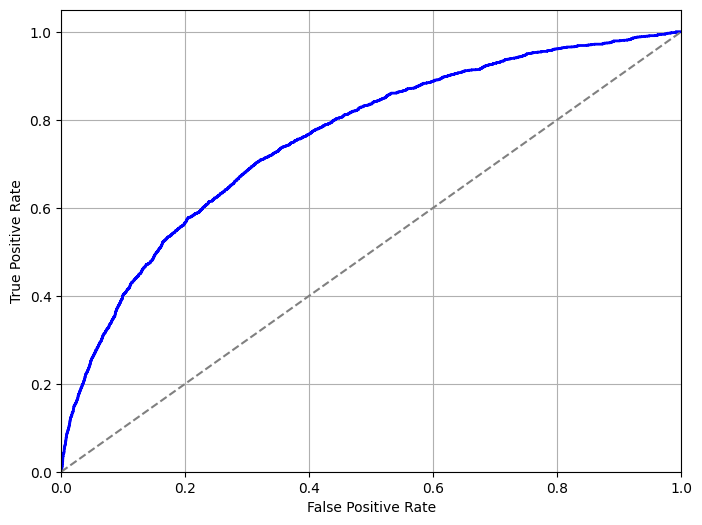

In [18]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.show()

In [19]:
metrics.auc(fpr,tpr)

0.7569180282053631

In [77]:
# remove feature below 0.1 importance and SK_ID_CURR 
#FLAG_EMP_PHONE: 0.006780131298429137
#FLAG_DOCUMENT_15: 0.0055933074719175776
#FLAG_DOCUMENT_11: 0.004443370410988771
#FLAG_DOCUMENT_20: 0.00188086605008125
#FLAG_EMAIL: 0.0018556701017297208
#FLAG_DOCUMENT_7: 0.0012206626143462054
#FLAG_CONT_MOBILE: 0.0005340523453033783
#FLAG_MOBIL: 0.0
#FLAG_DOCUMENT_2: 0.0
#FLAG_DOCUMENT_4: 0.0
#FLAG_DOCUMENT_10: 0.0
#FLAG_DOCUMENT_12: 0.0
#FLAG_DOCUMENT_17: 0.0
#FLAG_DOCUMENT_8: 0.06661419873798227
#NAME_TYPE_SUITE: 0.05773881211392235
#FLAG_DOCUMENT_13: 0.03875595835511899
#REG_REGION_NOT_LIVE_REGION: 0.03303133580378354
#LIVE_REGION_NOT_WORK_REGION: 0.008826610556107586
#FLAG_DOCUMENT_14: 0.005275844654141233
#FLAG_DOCUMENT_21: 0.0047255306045461505
#FLAG_DOCUMENT_9: 0.003793441930648102
#FLAG_DOCUMENT_19: 0.003780669938151295
#FLAG_DOCUMENT_6: 0.0
#'NAME_TYPE_SUITE','FLAG_DOCUMENT_13','REG_REGION_NOT_LIVE_REGION','LIVE_REGION_NOT_WORK_REGION','FLAG_DOCUMENT_14','FLAG_DOCUMENT_21','FLAG_DOCUMENT_9','FLAG_DOCUMENT_19','FLAG_DOCUMENT_6'
X_train = X_train.drop(columns=['SK_ID_CURR','FLAG_EMP_PHONE','FLAG_DOCUMENT_15','FLAG_DOCUMENT_11','FLAG_DOCUMENT_20','FLAG_EMAIL','FLAG_DOCUMENT_7','FLAG_CONT_MOBILE','FLAG_MOBIL','FLAG_DOCUMENT_2','FLAG_DOCUMENT_4','FLAG_DOCUMENT_10','FLAG_DOCUMENT_12','FLAG_DOCUMENT_17','FLAG_DOCUMENT_8','FLAG_DOCUMENT_13','REG_REGION_NOT_LIVE_REGION','LIVE_REGION_NOT_WORK_REGION','FLAG_DOCUMENT_14','FLAG_DOCUMENT_21','FLAG_DOCUMENT_9','FLAG_DOCUMENT_19','FLAG_DOCUMENT_6'])
X_valid = X_valid.drop(columns=['SK_ID_CURR','FLAG_EMP_PHONE','FLAG_DOCUMENT_15','FLAG_DOCUMENT_11','FLAG_DOCUMENT_20','FLAG_EMAIL','FLAG_DOCUMENT_7','FLAG_CONT_MOBILE','FLAG_MOBIL','FLAG_DOCUMENT_2','FLAG_DOCUMENT_4','FLAG_DOCUMENT_10','FLAG_DOCUMENT_12','FLAG_DOCUMENT_17','FLAG_DOCUMENT_8','FLAG_DOCUMENT_13','REG_REGION_NOT_LIVE_REGION','LIVE_REGION_NOT_WORK_REGION','FLAG_DOCUMENT_14','FLAG_DOCUMENT_21','FLAG_DOCUMENT_9','FLAG_DOCUMENT_19','FLAG_DOCUMENT_6'])
X_test =   X_test.drop(columns=['SK_ID_CURR','FLAG_EMP_PHONE','FLAG_DOCUMENT_15','FLAG_DOCUMENT_11','FLAG_DOCUMENT_20','FLAG_EMAIL','FLAG_DOCUMENT_7','FLAG_CONT_MOBILE','FLAG_MOBIL','FLAG_DOCUMENT_2','FLAG_DOCUMENT_4','FLAG_DOCUMENT_10','FLAG_DOCUMENT_12','FLAG_DOCUMENT_17','FLAG_DOCUMENT_8','FLAG_DOCUMENT_13','REG_REGION_NOT_LIVE_REGION','LIVE_REGION_NOT_WORK_REGION','FLAG_DOCUMENT_14','FLAG_DOCUMENT_21','FLAG_DOCUMENT_9','FLAG_DOCUMENT_19','FLAG_DOCUMENT_6'])


In [52]:
categorical_cols = dftrainset.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_cols)

['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [181]:
#re-establish model
model = CatBoostClassifier(
    iterations = 1000,
    learning_rate = 0.02,
    depth = 6,
    verbose = 35
)

In [78]:
# new model test
model = CatBoostClassifier(
    iterations = 1156,
    learning_rate = 0.06,
    depth = 4,
    verbose = 50,
    l2_leaf_reg=4,
    border_count=256,
    early_stopping_rounds=100
)

In [79]:
# create new pools
train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_cols)
valid_pool = Pool(data=X_valid, label=y_valid, cat_features=categorical_cols)
test_pool = Pool(data=X_test, cat_features=categorical_cols)

In [80]:
# fit the model to the data
model.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True
)

0:	learn: 0.6290986	test: 0.6290691	best: 0.6290691 (0)	total: 339ms	remaining: 6m 31s
50:	learn: 0.2558197	test: 0.2548531	best: 0.2548531 (50)	total: 13.8s	remaining: 4m 59s
100:	learn: 0.2504572	test: 0.2498811	best: 0.2498811 (100)	total: 27.9s	remaining: 4m 50s
150:	learn: 0.2484528	test: 0.2481529	best: 0.2481529 (150)	total: 41.6s	remaining: 4m 36s
200:	learn: 0.2473645	test: 0.2473635	best: 0.2473635 (200)	total: 55.3s	remaining: 4m 22s
250:	learn: 0.2464343	test: 0.2466941	best: 0.2466941 (250)	total: 1m 8s	remaining: 4m 8s
300:	learn: 0.2456974	test: 0.2462887	best: 0.2462887 (300)	total: 1m 23s	remaining: 3m 56s
350:	learn: 0.2450714	test: 0.2459721	best: 0.2459721 (350)	total: 1m 37s	remaining: 3m 42s
400:	learn: 0.2445247	test: 0.2457075	best: 0.2457015 (396)	total: 1m 50s	remaining: 3m 27s
450:	learn: 0.2441167	test: 0.2455891	best: 0.2455890 (448)	total: 2m 4s	remaining: 3m 15s
500:	learn: 0.2437267	test: 0.2454288	best: 0.2454288 (500)	total: 2m 20s	remaining: 3m 3s
550

In [81]:
y_valid_pred = model.predict(valid_pool)

# get validation accuracy score
valid_accuracy = accuracy_score(y_valid, y_valid_pred)
print("Validation Accuracy: ", valid_accuracy)

Validation Accuracy:  0.9199388647708242


In [82]:
# prints classification report
print(classification_report(y_valid, y_valid_pred))

# prints y test predictions
y_test_pred = model.predict(X_test)
print("y test pred:", y_test_pred)

# prints y test prediction probabilities
y_test_pred_prob = model.predict_proba(X_test)
print(y_test_pred_prob)

# gather valid prediction probability for graph
y_valid_pred_prob = model.predict_proba(X_valid)[:, 1]

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56554
           1       0.56      0.02      0.05      4949

    accuracy                           0.92     61503
   macro avg       0.74      0.51      0.50     61503
weighted avg       0.89      0.92      0.88     61503

y test pred: [0 0 0 ... 0 0 0]
[[0.96041273 0.03958727]
 [0.84063494 0.15936506]
 [0.98269503 0.01730497]
 ...
 [0.96223445 0.03776555]
 [0.93183616 0.06816384]
 [0.8382766  0.1617234 ]]


In [83]:
y_score = model.predict_proba(X_test)[:, 1]
print(y_score)

[0.03958727 0.15936506 0.01730497 ... 0.03776555 0.06816384 0.1617234 ]


In [84]:
fpr, tpr, _ = roc_curve(y_valid, y_valid_pred_prob)
roc_auc = auc(fpr, tpr)

In [85]:
metrics.auc(fpr,tpr)

0.761288157918553

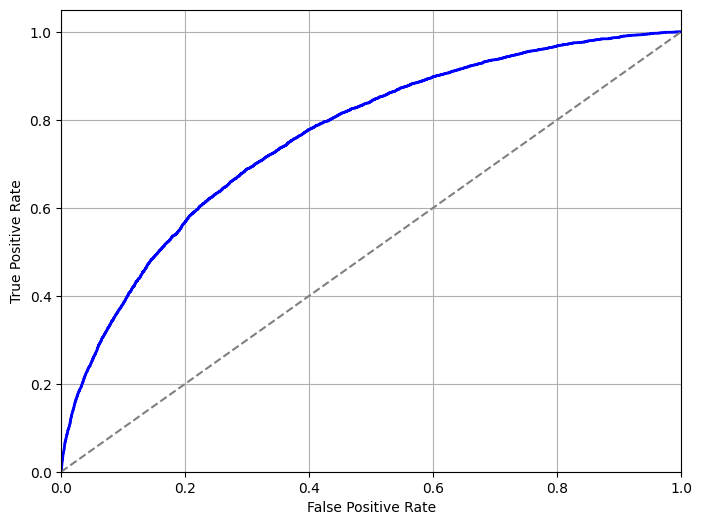

In [86]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.show()

In [87]:
testids = dftestset['SK_ID_CURR']
print(testids)

0        100001
1        100005
2        100013
3        100028
4        100038
          ...  
48739    456221
48740    456222
48741    456223
48742    456224
48743    456250
Name: SK_ID_CURR, Length: 48744, dtype: int64


In [88]:
dfsubmission = pd.DataFrame({
    'SK_ID_CURR' : testids,
    'TARGET' : y_score
})

dfsubmission

,SK_ID_CURR,TARGET
0,100001,0.039587
1,100005,0.159365
2,100013,0.017305
3,100028,0.041964
4,100038,0.147769
...,...,...
48739,456221,0.032545
48740,456222,0.090215
48741,456223,0.037766
48742,456224,0.068164


C:\Users\bhyde\AppData\Local\Temp\ipykernel_2156\96526877.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dfsubmission['TARGET'], shade=True)


<Axes: xlabel='TARGET', ylabel='Density'>

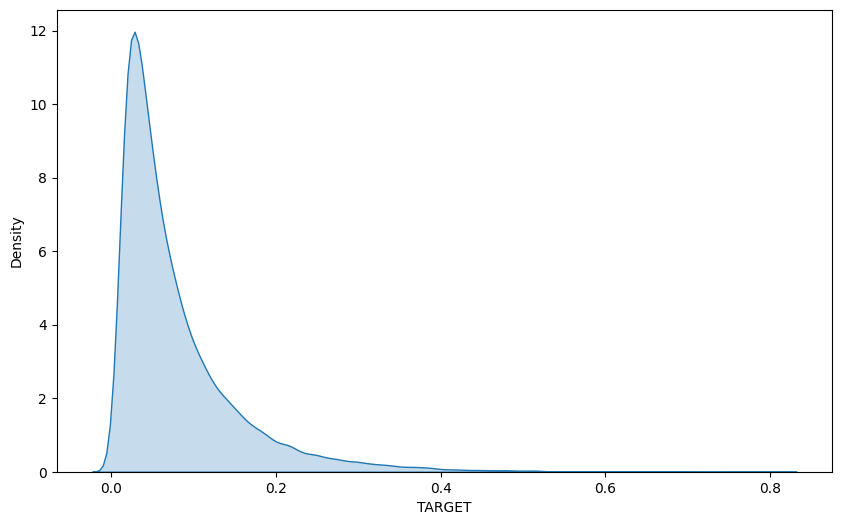

In [89]:
plt.figure(figsize=(10,6))
sns.kdeplot(dfsubmission['TARGET'], shade=True)

In [90]:
dfsubmission.to_csv('./output/submission.csv', index=False)